In [10]:

from QHED import *

# Quantum Hadamard Edge Detection
To implement QHED, our first step is to encode a given image into a quantum state. We use amplitude encoding for this so QuantumCircuit.initialize is a suitable method for encoding our image. However, some pre-processing may be required depending on image size (i.e. downscalling or image batching).

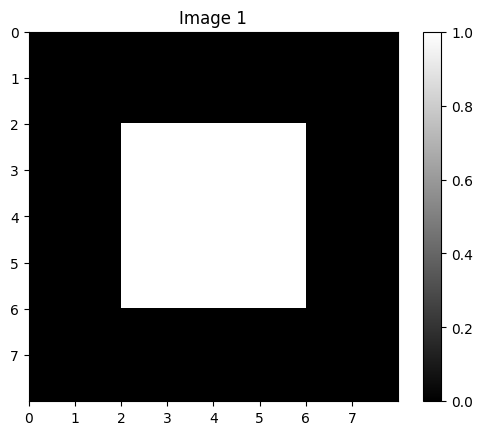

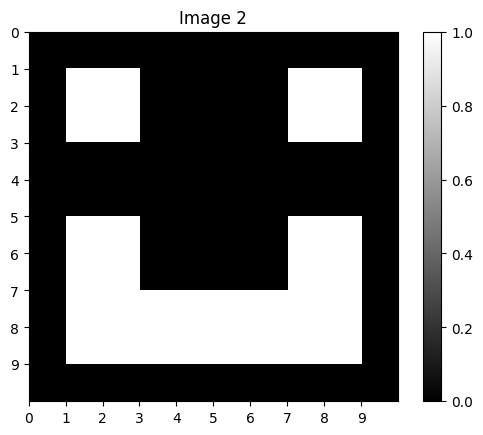

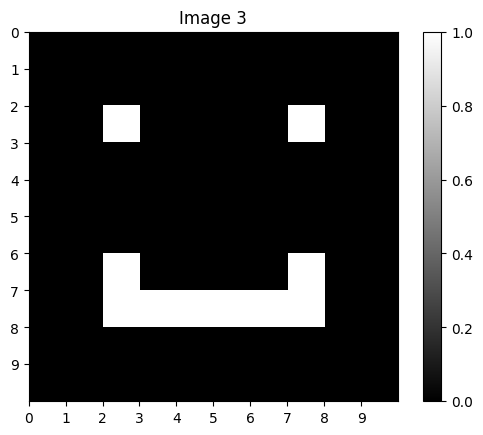

In [2]:
img1 = np.array([[0, 0, 0, 0, 0, 0, 0, 0],
                [0, 0, 0, 0, 0, 0, 0, 0],
                [0, 0, 1, 1, 1, 1, 0, 0],
                [0, 0, 1, 1, 1, 1, 0, 0],
                [0, 0, 1, 1, 1, 1, 0, 0],
                [0, 0, 1, 1, 1, 1, 0, 0],
                [0, 0, 0, 0, 0, 0, 0, 0],
                [0, 0, 0, 0, 0, 0, 0, 0]])

img2 = np.array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                [0, 1, 1, 0, 0, 0, 0, 1, 1, 0],
                [0, 1, 1, 0, 0, 0, 0, 1, 1, 0],
                [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                [0, 1, 1, 0, 0, 0, 0, 1, 1, 0],
                [0, 1, 1, 0, 0, 0, 0, 1, 1, 0],
                [0, 1, 1, 1, 1, 1, 1, 1, 1, 0],
                [0, 1, 1, 1, 1, 1, 1, 1, 1, 0],
                [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])

img3 = np.array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                [0, 0, 1, 0, 0, 0, 0, 1, 0, 0],
                [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                [0, 0, 1, 0, 0, 0, 0, 1, 0, 0],
                [0, 0, 1, 1, 1, 1, 1, 1, 0, 0],
                [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])

plot_image(img1, 'Image 1')
plot_image(img2, 'Image 2')
plot_image(img3, 'Image 3')

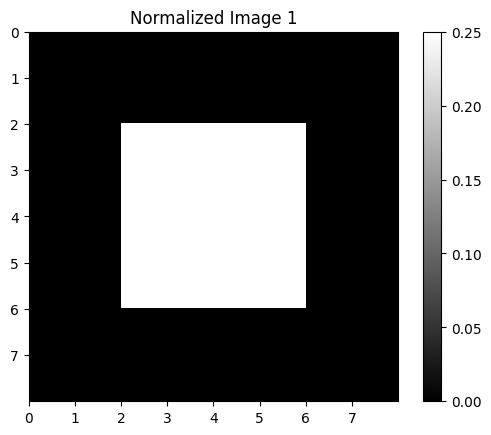

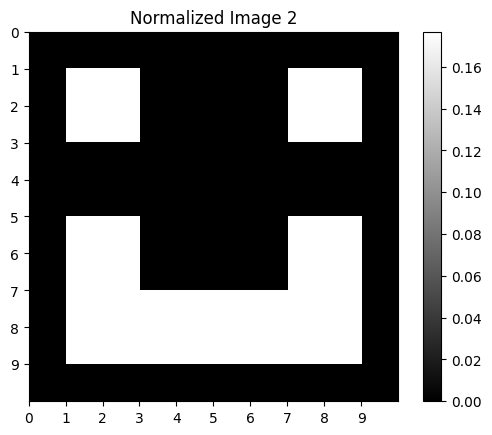

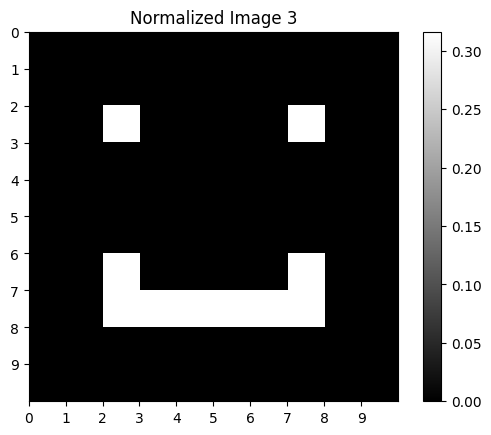

In [3]:
norm_img1 = normalize_image(img1)
norm_img2 = normalize_image(img2)
norm_img3 = normalize_image(img3)

plot_image(norm_img1, 'Normalized Image 1')
plot_image(norm_img2, 'Normalized Image 2')
plot_image(norm_img3, 'Normalized Image 3')

[checkpoint] Cell 5 start: toy-image validation using QHED class
[checkpoint] img2 statevector result count: 2


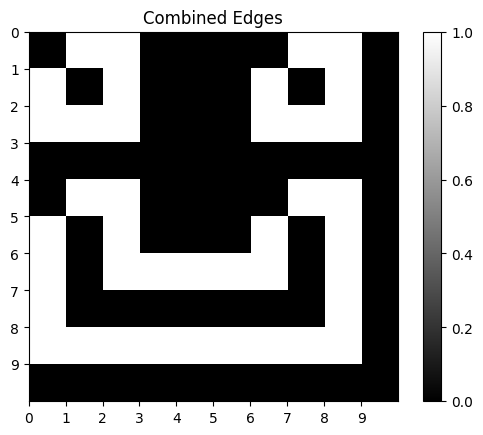

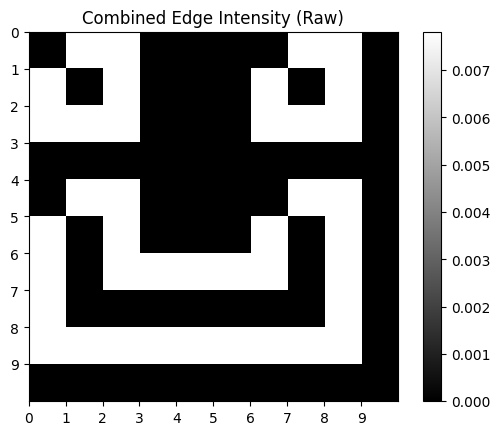

[checkpoint] img2 measurement result count: 2


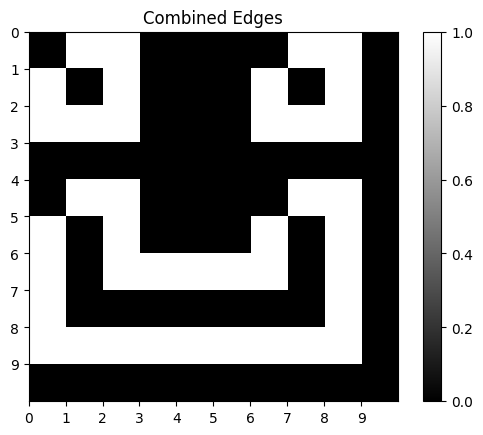

[checkpoint] img3 statevector result count: 2


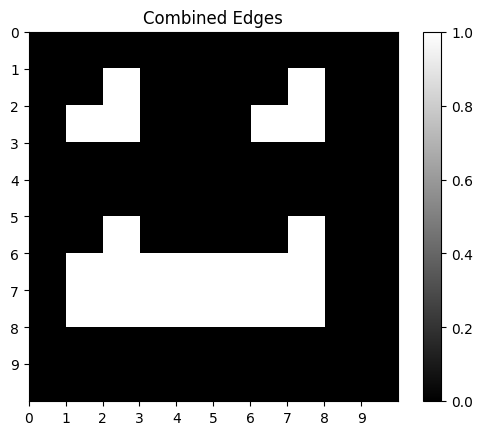

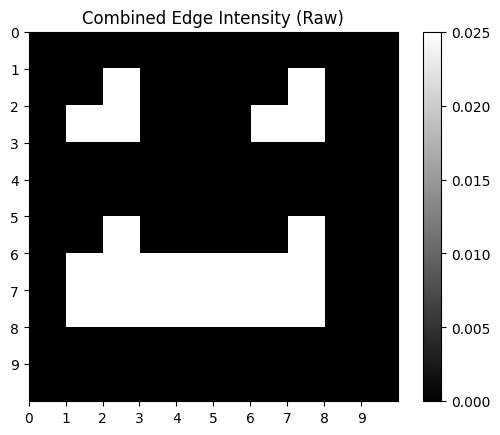

[checkpoint] Cell 5 done: toy-image validation complete


In [ ]:
#state vector
qhed1 = QHED(img2, measure=False, display=True)
print('statevector mode result count:', len(qhed1.results))
qhed1.plot_results()

# test with measurement
qhed2 = QHED(img2, measure=True, display=Fa, shots=1024)
print('measurement mode result count:', len(qhed2.results))
qhed2.plot_results()

qhed3 = QHED(img3, measure=True, display=False, shots=50000)
qhed3.plot_results()
qhed3.plot_raw_results()


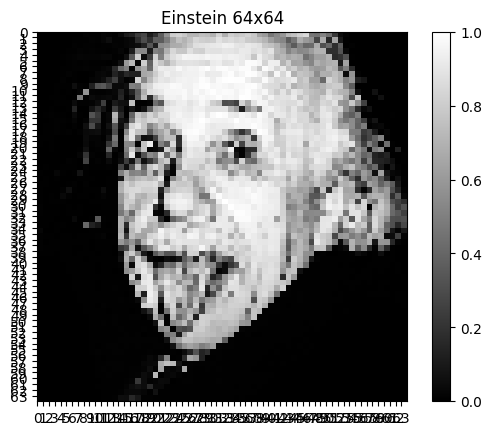

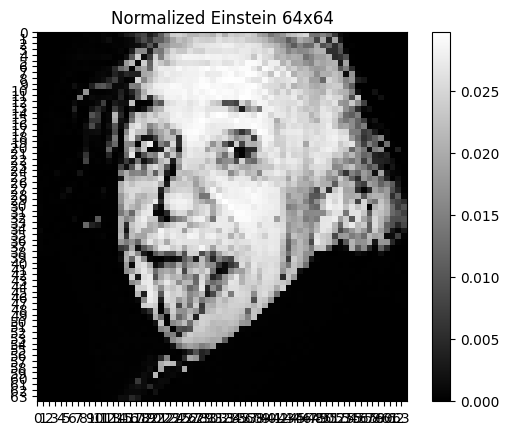

Einstein statevector mode result count: 2


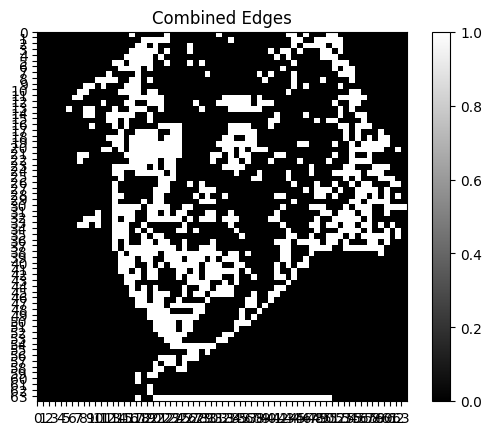

In [20]:
# try on Einstein image (downsampled to keep statevector simulation tractable)
img = plt.imread('einstein.png')
img_gray = np.mean(img[..., :3], axis=2) if img.ndim == 3 else img
img_gray = np.asarray(img_gray, dtype=np.float64)

# Resize with index mapping (no extra dependency needed).
target_h, target_w = 64, 64
r_idx = np.linspace(0, img_gray.shape[0] - 1, target_h).astype(int)
c_idx = np.linspace(0, img_gray.shape[1] - 1, target_w).astype(int)
img_small = img_gray[np.ix_(r_idx, c_idx)]

plot_image(img_small, 'Einstein 64x64')

norm_img = normalize_image(img_small)
plot_image(norm_img, 'Normalized Einstein 64x64')

# Important: run QHED on normalized, downsampled data.
qhed_einstein = QHED(norm_img, measure=True, display=False, shots = 50000)
print('Einstein statevector mode result count:', len(qhed_einstein.results))
qhed_einstein.plot_results()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage

def load_einstein_gray(path="einstein.png"):
    print(f"[checkpoint] Loading image: {path}")
    img = plt.imread(path)
    if img.ndim == 3:
        img = np.mean(img[..., :3], axis=2)
    out = np.asarray(img, dtype=np.float64)
    print(f"[checkpoint] Loaded grayscale image with shape: {out.shape}")
    return out


def resize_nearest(img_gray, target_h, target_w):
    r_idx = np.linspace(0, img_gray.shape[0] - 1, target_h).astype(int)
    c_idx = np.linspace(0, img_gray.shape[1] - 1, target_w).astype(int)
    return img_gray[np.ix_(r_idx, c_idx)]


def normalize_for_display(image):
    image = np.asarray(image, dtype=np.float64)
    mn, mx = float(np.min(image)), float(np.max(image))
    if mx <= mn:
        return np.zeros_like(image)
    return (image - mn) / (mx - mn)


def sobel_gradient_map(image):
    gx = ndimage.sobel(image, axis=1, mode="reflect")
    gy = ndimage.sobel(image, axis=0, mode="reflect")
    grad = np.hypot(gx, gy)
    return grad


def finite_difference_gradient_map(image):
    # Classical baseline most comparable to QHED: first-order differences without smoothing.
    gx = np.zeros_like(image, dtype=np.float64)
    gy = np.zeros_like(image, dtype=np.float64)
    gx[:, :-1] = image[:, 1:] - image[:, :-1]
    gy[:-1, :] = image[1:, :] - image[:-1, :]
    return np.maximum(np.abs(gx), np.abs(gy))


def combined_edges_for_threshold(qhed_obj, threshold):
    edges = []
    for idx, result in enumerate(qhed_obj.results):
        flat_probs = qhed_obj.result_to_flat_probabilities(result)
        flat_edge = (flat_probs > threshold).astype(int)
        edge_img = qhed_obj.flat_to_edge_image(flat_edge, idx)
        edges.append(edge_img)
    return np.logical_or(edges[0], edges[1]).astype(int)


def combined_gradient_map(qhed_obj):
    grads = []
    for idx, result in enumerate(qhed_obj.results):
        flat_probs = qhed_obj.result_to_flat_probabilities(result)
        grad_img = qhed_obj.flat_to_edge_image(flat_probs, idx)
        grads.append(grad_img)
    return np.maximum(grads[0], grads[1])


def run_scale_sweep_with_results(img_gray, sizes, edge_threshold=1e-5):
    # This run is for producing output images only.
    print(f"[checkpoint] Scale sweep start for sizes: {sizes}")
    records = []
    for size in sizes:
        print(f"[checkpoint] Scale sweep: running QHED for {size}x{size}")
        resized = resize_nearest(img_gray, size, size)
        qhed_obj = QHED(resized, measure=False, display=False, edge_threshold=edge_threshold)
        combined = combined_edges_for_threshold(qhed_obj, edge_threshold)
        qhed_grad = combined_gradient_map(qhed_obj)
        classical_diff_grad = finite_difference_gradient_map(resized)
        sobel_grad = sobel_gradient_map(resized)
        records.append({
            "size": size,
            "image": resized,
            "qhed": qhed_obj,
            "combined_edges": combined,
            "qhed_gradient": qhed_grad,
            "classical_diff_gradient": classical_diff_grad,
            "sobel_gradient": sobel_grad,
        })
    print("[checkpoint] Scale sweep complete")
    return records


def plot_scale_comparison_panel(scale_records):
    print("[checkpoint] Plotting scale comparison panel")
    row_count = len(scale_records)
    fig, axes = plt.subplots(row_count, 5, figsize=(15, 3.2 * row_count))

    if row_count == 1:
        axes = np.expand_dims(axes, axis=0)

    labels = ["Raw Image", "Raw QHED Output", "PP QHED Output", "Classical Diff", "Sobel"]

    for row_idx, record in enumerate(scale_records):
        raw_norm = normalize_for_display(record["image"])
        qhed_grad_norm = normalize_for_display(record["qhed_gradient"])
        qhed_edge_bin = record["combined_edges"].astype(np.float64)
        classical_diff_norm = normalize_for_display(record["classical_diff_gradient"])
        sobel_grad_norm = normalize_for_display(record["sobel_gradient"])

        images = [raw_norm, qhed_grad_norm, qhed_edge_bin, classical_diff_norm, sobel_grad_norm]

        for col_idx, img in enumerate(images):
            ax = axes[row_idx, col_idx]
            ax.imshow(img, cmap="gray", vmin=0.0, vmax=1.0)
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_xlabel(labels[col_idx], labelpad=6)

        axes[row_idx, 0].set_ylabel(f"{record['size']}x{record['size']}", rotation=0, labelpad=36, va="center")

    fig.suptitle("QHED vs Classical Edge Baselines by Size")
    plt.tight_layout()
    plt.show()


def build_log_thresholds_from_gradient(qhed_obj, n_levels=6, min_ratio=1e-3, include_zero=True):
    print("[checkpoint] Building log thresholds from gradient max")
    gmax = float(np.max(combined_gradient_map(qhed_obj)))
    if gmax <= 0:
        return [0.0]
    n_pos = n_levels - 1 if include_zero else n_levels
    n_pos = max(1, n_pos)
    vals = np.geomspace(gmax * min_ratio, gmax, num=n_pos)
    return ([0.0] if include_zero else []) + [float(v) for v in vals]


def fmt_threshold(t):
    if t == 0:
        return "0"
    if t < 1e-2:
        return f"{t:.2e}"
    return f"{t:.4f}"


def plot_threshold_sweep_grid(qhed_obj, thresholds):
    print(f"[checkpoint] Plotting threshold sweep with {len(thresholds)} levels")
    n = len(thresholds)
    cols = min(3, n)
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)

    for i, t in enumerate(thresholds):
        edges = combined_edges_for_threshold(qhed_obj, t)
        axes[i].imshow(edges, cmap="gray")
        axes[i].set_title(f"Threshold={fmt_threshold(t)}")
        axes[i].axis("off")

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    fig.suptitle("QHED Binary Edge Output vs Log-Scaled Threshold")
    plt.tight_layout()
    plt.show()


print("[checkpoint] Helper cell ready")

[checkpoint] Helper cell: imports loaded
[checkpoint] Helper cell ready


[checkpoint] Cell 9 start: scale comparison setup (class-driven)
[checkpoint] Cell 9: building QHED object for 16x16
[checkpoint] Cell 9: building QHED object for 32x32
[checkpoint] Cell 9: building QHED object for 64x64
[checkpoint] Plotting scale comparison panel


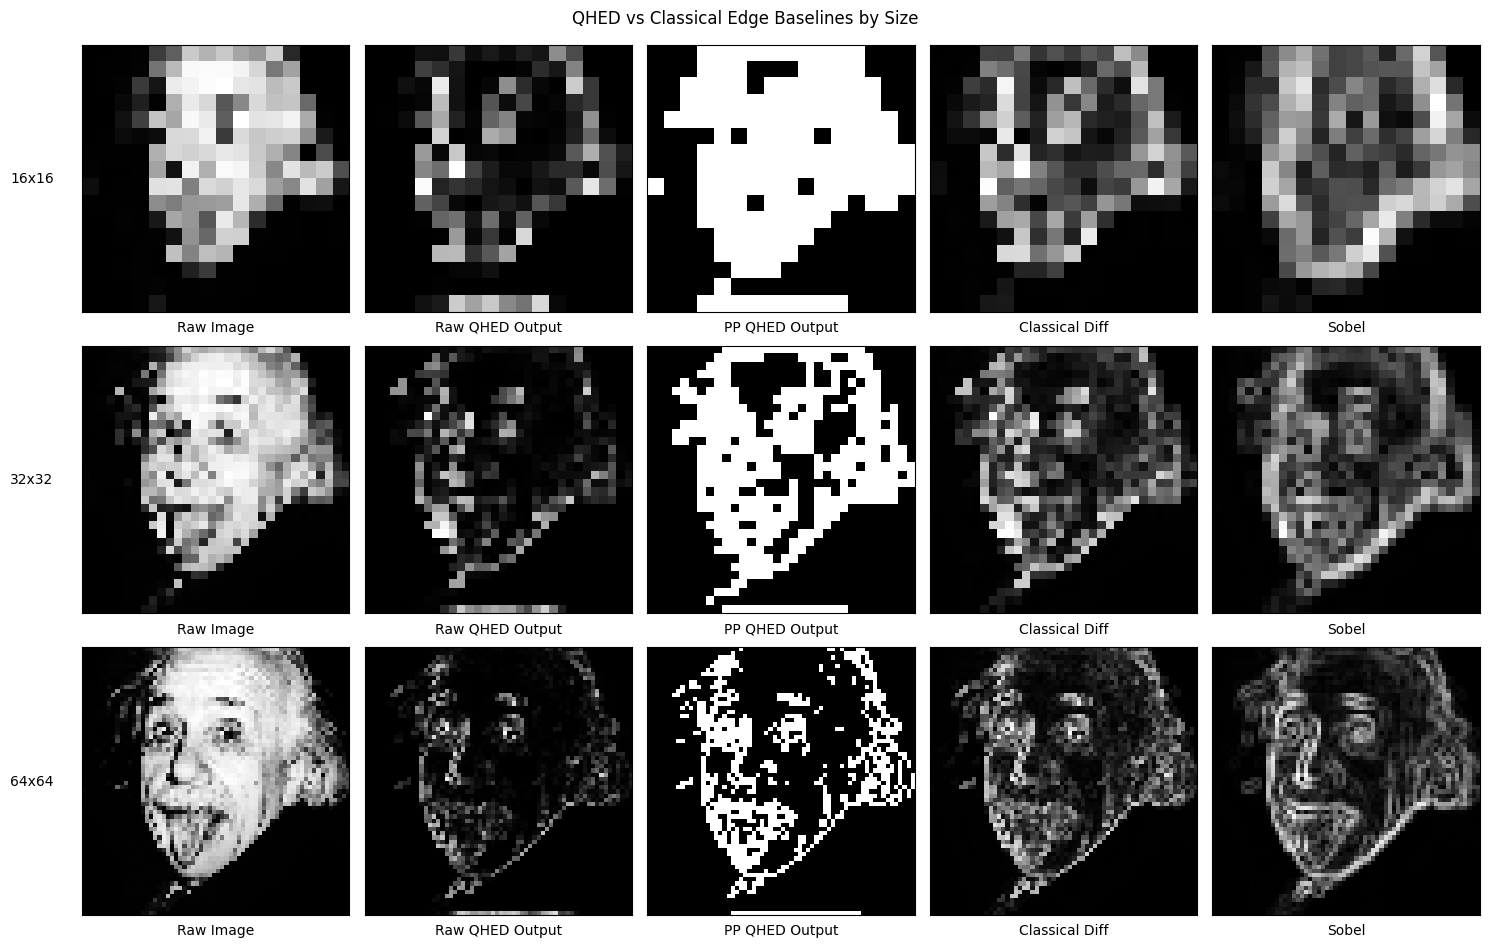

[checkpoint] Cell 9 done: scale comparison figure generated


In [ ]:
einstein_gray = load_einstein_gray("einstein.png")

scale_sizes = [16, 32, 64]
scale_records = []

for size in scale_sizes:
    print(f"[checkpoint] Cell 9: building QHED object for {size}x{size}")
    resized = resize_nearest(einstein_gray, size, size)
    qhed_obj = QHED(resized, measure=False, display=False, edge_threshold=1e-5)

    # Use class outputs for QHED maps.
    qhed_grad = combined_gradient_map(qhed_obj)
    qhed_edges = combined_edges_for_threshold(qhed_obj, threshold=1e-5)

    # Classical baselines for comparison only.
    classical_diff_grad = finite_difference_gradient_map(resized)
    sobel_grad = sobel_gradient_map(resized)

    scale_records.append({
        "size": size,
        "image": resized,
        "qhed": qhed_obj,
        "combined_edges": qhed_edges,
        "qhed_gradient": qhed_grad,
        "classical_diff_gradient": classical_diff_grad,
        "sobel_gradient": sobel_grad,
    })

plot_scale_comparison_panel(scale_records)
print("[checkpoint] Cell 9 done: scale comparison figure generated")

[checkpoint] Cell 10 start: log-threshold sweep (class-driven)
[checkpoint] Building log thresholds from gradient max
[checkpoint] Thresholds: [0.0, 1.8862701240998534e-07, 1.0607276412532754e-06, 5.964909874484001e-06, 3.354315323458332e-05, 0.00018862701240998533]
[checkpoint] Plotting threshold sweep with 6 levels


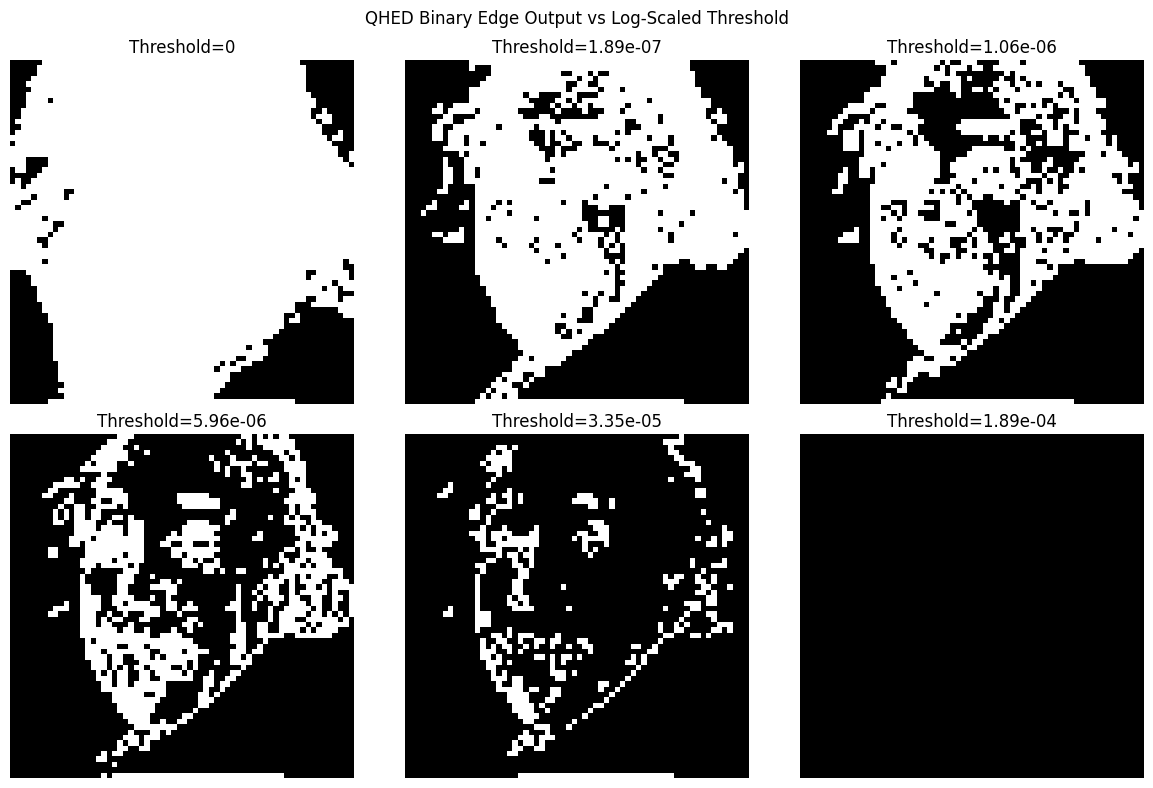

[checkpoint] Cell 10 done: threshold sweep figure generated


In [18]:
print("[checkpoint] Cell 10 start: log-threshold sweep (class-driven)")

if "scale_records" not in globals() or len(scale_records) == 0:
    raise RuntimeError("Run Cell 9 first to create scale_records and QHED objects.")

qhed_64 = next(r["qhed"] for r in scale_records if r["size"] == 64)
thresholds = build_log_thresholds_from_gradient(qhed_64, n_levels=6, min_ratio=1e-3, include_zero=True)
print("[checkpoint] Thresholds:", thresholds)
plot_threshold_sweep_grid(qhed_64, thresholds)
print("[checkpoint] Cell 10 done: threshold sweep figure generated")

[checkpoint] Cell 11 start: Einstein raw-output visualization (class-driven)


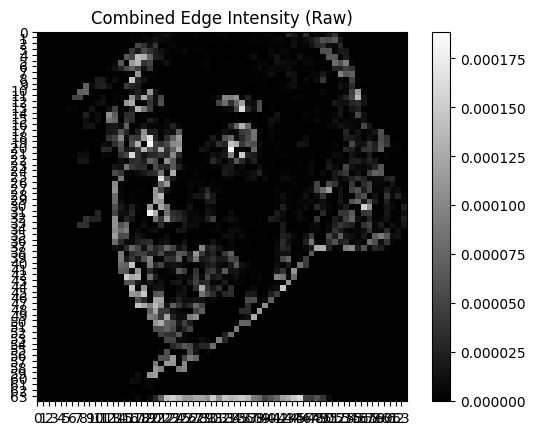

[checkpoint] Cell 11 done


In [19]:
print("[checkpoint] Cell 11 start: Einstein raw-output visualization (class-driven)")

if "qhed_64" not in globals():
    if "scale_records" not in globals() or len(scale_records) == 0:
        raise RuntimeError("Run Cell 9 first to generate a 64x64 QHED object.")
    qhed_64 = next(r["qhed"] for r in scale_records if r["size"] == 64)

qhed_64.plot_raw_results()
print("[checkpoint] Cell 11 done")